# Лабораторная работа №3
## Эволюционная программа для решения задачи искусственного муравья

## 1. Импорт библиотек

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from copy import deepcopy
from IPython.display import display
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)

## 2. Параметры задачи и поля

In [2]:
# ── Параметры поля ──────────────────────────────────────────────
GRID_SIZE    = 32       # размер поля N×N
FOOD_DENSITY = 0.15     # доля клеток с едой
OBS_DENSITY  = 0.05     # доля клеток с препятствиями
START_POS    = (0, 0)   # начальная позиция муравья
START_DIR    = 0        # начальное направление: 0=вверх,1=вправо,2=вниз,3=влево
MAX_STEPS    = 600      # максимальное число шагов симуляции
CYCLIC_FIELD = True     # цикличность поля

# ── Параметры конечного автомата ────────────────────────────────
NUM_STATES   = 6        # количество состояний КА

# Типы клеток
CELL_EMPTY   = 0
CELL_FOOD    = 1
CELL_OBSTACLE= 2

# Действия муравья
ACT_FORWARD  = 0   # шаг вперёд
ACT_LEFT     = 1   # повернуть налево
ACT_RIGHT    = 2   # повернуть направо
ACT_EAT      = 3   # съесть еду (на текущей клетке)

ACTION_NAMES = {ACT_FORWARD: 'Вперёд', ACT_LEFT: 'Налево',
                ACT_RIGHT: 'Направо', ACT_EAT: 'Съесть'}
NUM_ACTIONS  = 4
NUM_INPUTS   = 3   # тип клетки перед муравьём (пусто/еда/препятствие)

# ── Параметры эволюционного алгоритма ───────────────────────────
POP_SIZE     = 120      # размер популяции
NUM_GEN      = 150      # количество поколений
ELITE_FRAC   = 0.10     # доля элитных особей
MUTATE_PROB  = 0.25     # вероятность мутации одной особи
MUTATE_GENE  = 0.20     # вероятность мутации каждого гена
ADD_DEL_PROB = 0.05     # вероятность добавления/удаления состояния
MIN_STATES   = 2
MAX_STATES   = 12

print('Параметры задачи инициализированы.')

Параметры задачи инициализированы.


## 3. Генерация поля и вспомогательные функции

Всего еды на поле: 167


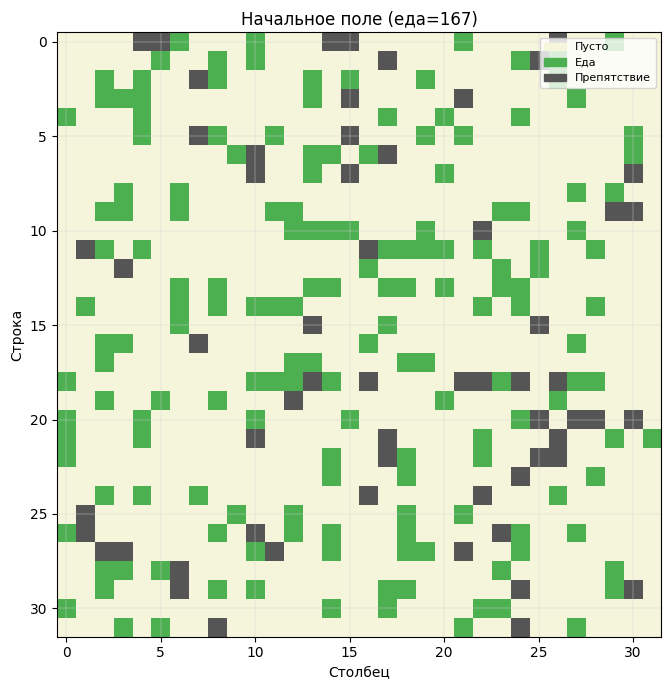

In [3]:
def generate_field(grid_size=GRID_SIZE,
                   food_density=FOOD_DENSITY,
                   obs_density=OBS_DENSITY,
                   start_pos=START_POS,
                   seed=None):
    """Создаёт поле grid_size×grid_size.
    Возвращает numpy-массив: 0=пусто, 1=еда, 2=препятствие.
    Начальная клетка и несколько соседних гарантированно пусты.
    """
    if seed is not None:
        np.random.seed(seed)
    field = np.zeros((grid_size, grid_size), dtype=int)
    rng   = np.random.random((grid_size, grid_size))
    field[rng < food_density]                          = CELL_FOOD
    field[(rng >= food_density) & (rng < food_density + obs_density)] = CELL_OBSTACLE
    # Начальная зона всегда пуста
    r, c = start_pos
    for dr in range(-1, 2):
        for dc in range(-1, 2):
            nr, nc = (r + dr) % grid_size, (c + dc) % grid_size
            field[nr, nc] = CELL_EMPTY
    return field


def count_food(field):
    return int(np.sum(field == CELL_FOOD))


# Направления: 0=север(↑), 1=восток(→), 2=юг(↓), 3=запад(←)
DIR_DR = [-1,  0,  1,  0]
DIR_DC = [ 0,  1,  0, -1]
DIR_NAMES = ['↑', '→', '↓', '←']


def next_cell(r, c, direction, grid_size=GRID_SIZE, cyclic=CYCLIC_FIELD):
    """Координаты клетки перед муравьём."""
    nr = r + DIR_DR[direction]
    nc = c + DIR_DC[direction]
    if cyclic:
        nr %= grid_size
        nc %= grid_size
    else:
        nr = max(0, min(grid_size - 1, nr))
        nc = max(0, min(grid_size - 1, nc))
    return nr, nc


# Визуализация поля
def plot_field(field, path=None, title='Поле', ax=None):
    show = ax is None
    if show:
        fig, ax = plt.subplots(figsize=(7, 7))
    cmap = ListedColormap(['#f5f5dc', '#4caf50', '#555555'])  # пусто/еда/препятствие
    ax.imshow(field, cmap=cmap, vmin=0, vmax=2, origin='upper')
    if path and len(path) > 1:
        rows = [p[0] for p in path]
        cols = [p[1] for p in path]
        ax.plot(cols, rows, '-', color='royalblue', linewidth=0.8, alpha=0.7, label='Путь')
        # Старт
        ax.scatter(cols[0], rows[0], c='lime', s=80, zorder=5, label='Старт')
        # Финиш
        ax.scatter(cols[-1], rows[-1], c='red', s=80, marker='*', zorder=5, label='Финиш')
    legend_patches = [
        mpatches.Patch(color='#f5f5dc', label='Пусто'),
        mpatches.Patch(color='#4caf50', label='Еда'),
        mpatches.Patch(color='#555555', label='Препятствие'),
    ]
    if path:
        legend_patches += [
            mpatches.Patch(color='royalblue', label='Путь'),
            mpatches.Patch(color='lime',      label='Старт'),
            mpatches.Patch(color='red',       label='Финиш'),
        ]
    ax.legend(handles=legend_patches, loc='upper right', fontsize=8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Столбец'); ax.set_ylabel('Строка')
    ax.grid(True, which='both', color='lightgray', linewidth=0.3)
    if show:
        plt.tight_layout()
        plt.show()


# Отображаем сгенерированное поле
BASE_FIELD = generate_field(seed=42)
total_food = count_food(BASE_FIELD)
print(f'Всего еды на поле: {total_food}')
plot_field(BASE_FIELD, title=f'Начальное поле (еда={total_food})')

## 4. Конечный автомат — представление и симуляция

In [4]:
class FiniteAutomaton:
    """
    Конечный автомат для управления муравьём.

    Генотип:
        transitions[s][i] = (action, next_state)
            s ∈ {0..num_states-1},
            i ∈ {0=пусто, 1=еда, 2=препятствие} — тип клетки ПЕРЕД муравьём,
            action ∈ {0=Вперёд, 1=Налево, 2=Направо, 3=Съесть},
            next_state ∈ {0..num_states-1}.
    """

    def __init__(self, num_states=NUM_STATES):
        self.num_states  = num_states
        # transitions[state][input] = [action, next_state]
        self.transitions = [
            [[random.randint(0, NUM_ACTIONS - 1),
              random.randint(0, num_states - 1)]
             for _ in range(NUM_INPUTS)]
            for _ in range(num_states)
        ]

    # ── Запуск симуляции ─────────────────────────────────────────
    def simulate(self, field, start_pos=START_POS, start_dir=START_DIR,
                 max_steps=MAX_STEPS, cyclic=CYCLIC_FIELD):
        """
        Симулирует движение муравья по копии поля.
        Возвращает (food_collected, path, actions_taken).
        """
        grid       = field.copy()
        gs         = grid.shape[0]
        r, c       = start_pos
        direction  = start_dir
        state      = 0
        food_eaten = 0
        path       = [(r, c)]
        actions    = []

        for _ in range(max_steps):
            nr, nc = next_cell(r, c, direction, gs, cyclic)
            front  = grid[nr, nc]          # тип клетки перед муравьём

            action, state = self.transitions[state][front]

            if action == ACT_FORWARD:
                if grid[nr, nc] != CELL_OBSTACLE:
                    r, c = nr, nc
                    if grid[r, c] == CELL_FOOD:
                        food_eaten    += 1
                        grid[r, c]     = CELL_EMPTY
            elif action == ACT_LEFT:
                direction = (direction - 1) % 4
            elif action == ACT_RIGHT:
                direction = (direction + 1) % 4
            elif action == ACT_EAT:
                if grid[r, c] == CELL_FOOD:
                    food_eaten    += 1
                    grid[r, c]     = CELL_EMPTY

            path.append((r, c))
            actions.append(action)

        return food_eaten, path, actions

    # ── Вспомогательные методы ───────────────────────────────────
    def clone(self):
        fa = FiniteAutomaton.__new__(FiniteAutomaton)
        fa.num_states  = self.num_states
        fa.transitions = deepcopy(self.transitions)
        return fa

    def transition_table(self):
        """Возвращает pandas DataFrame с таблицей переходов."""
        rows = []
        input_names = ['Пусто', 'Еда', 'Препятствие']
        for s in range(self.num_states):
            for i, inp in enumerate(input_names):
                act, ns = self.transitions[s][i]
                rows.append({
                    'Состояние': s,
                    'Вход': inp,
                    'Действие': ACTION_NAMES[act],
                    'След. состояние': ns
                })
        return pd.DataFrame(rows)


# Быстрая проверка
test_fa   = FiniteAutomaton(num_states=4)
food, path, acts = test_fa.simulate(BASE_FIELD)
print(f'Тест случайного КА: еда={food}, шагов={len(path)}')

Тест случайного КА: еда=0, шагов=601


## 5. Операторы эволюционного алгоритма

Используется **эволюционная стратегия (ES)** — не генетический алгоритм.  
Особенности:
- Отбор — **турнирный** (µ, λ)-стратегия
- **Элитизм** — лучшие `ELITE_FRAC` особей переносятся без изменений
- Мутации двух видов: точечная (изменение правила перехода) и структурная (добавление / удаление состояния)
- Кроссовер — однородный обмен строками таблицы переходов между двумя родителями

In [5]:
# ── Фитнес ───────────────────────────────────────────────────────
def fitness(fa, field):
    """Фитнес = количество собранной еды."""
    food, _, _ = fa.simulate(field)
    return food


# ── Начальная популяция ──────────────────────────────────────────
def init_population(pop_size=POP_SIZE, num_states=NUM_STATES):
    return [FiniteAutomaton(num_states) for _ in range(pop_size)]


# ── Оценка популяции ─────────────────────────────────────────────
def evaluate_population(population, field):
    return [fitness(fa, field) for fa in population]


# ── Турнирный отбор ──────────────────────────────────────────────
def tournament_select(population, fitnesses, k=3):
    """Возвращает одного победителя турнира из k случайных особей."""
    candidates = random.sample(range(len(population)), k)
    winner     = max(candidates, key=lambda i: fitnesses[i])
    return population[winner].clone()


# ── Кроссовер (обмен строками таблицы переходов) ─────────────────
def crossover(fa1, fa2):
    """Однородный кроссовер: для каждого состояния (по min числу состояний)
    с вероятностью 0.5 берём строку от fa1, иначе от fa2."""
    child = fa1.clone()
    n     = min(fa1.num_states, fa2.num_states)
    for s in range(n):
        if random.random() < 0.5:
            child.transitions[s] = deepcopy(fa2.transitions[s])
    # Фиксируем next_state, чтобы не выходил за пределы
    for s in range(child.num_states):
        for i in range(NUM_INPUTS):
            child.transitions[s][i][1] %= child.num_states
    return child


# ── Мутация ───────────────────────────────────────────────────────
def mutate(fa,
           mutate_gene=MUTATE_GENE,
           add_del_prob=ADD_DEL_PROB,
           min_states=MIN_STATES,
           max_states=MAX_STATES):
    """Мутирует копию КА и возвращает её."""
    child = fa.clone()

    # Точечная мутация: изменение действия или следующего состояния
    for s in range(child.num_states):
        for i in range(NUM_INPUTS):
            if random.random() < mutate_gene:
                if random.random() < 0.5:
                    child.transitions[s][i][0] = random.randint(0, NUM_ACTIONS - 1)
                else:
                    child.transitions[s][i][1] = random.randint(0, child.num_states - 1)

    # Структурная мутация: добавление нового состояния
    if random.random() < add_del_prob and child.num_states < max_states:
        new_row = [[random.randint(0, NUM_ACTIONS - 1),
                    random.randint(0, child.num_states)]  # может указывать на новое
                   for _ in range(NUM_INPUTS)]
        child.transitions.append(new_row)
        child.num_states += 1
        # Фиксируем next_state
        for s in range(child.num_states):
            for i in range(NUM_INPUTS):
                child.transitions[s][i][1] %= child.num_states

    # Структурная мутация: удаление случайного состояния (не нулевого)
    elif random.random() < add_del_prob and child.num_states > min_states:
        del_idx = random.randint(1, child.num_states - 1)
        child.transitions.pop(del_idx)
        child.num_states -= 1
        # Переиндексация next_state
        for s in range(child.num_states):
            for i in range(NUM_INPUTS):
                ns = child.transitions[s][i][1]
                if ns >= child.num_states:
                    child.transitions[s][i][1] = ns % child.num_states

    return child


print('Операторы эволюционного алгоритма определены.')

Операторы эволюционного алгоритма определены.


## 6. Главный цикл эволюционного алгоритма

In [6]:
def run_evolution(
        field,
        pop_size   = POP_SIZE,
        num_gen    = NUM_GEN,
        elite_frac = ELITE_FRAC,
        mutate_prob= MUTATE_PROB,
        num_states = NUM_STATES,
        verbose    = True
):
    """
    Запускает эволюционный алгоритм.
    Возвращает (best_fa, history) где history — список (best_fit, mean_fit) по поколениям.
    """
    n_elite = max(1, int(pop_size * elite_frac))

    population = init_population(pop_size, num_states)
    fitnesses  = evaluate_population(population, field)

    history    = []
    best_ever  = None
    best_fit   = -1

    for gen in range(num_gen):
        # Сортировка по убыванию фитнеса
        order      = sorted(range(pop_size), key=lambda i: fitnesses[i], reverse=True)
        population = [population[i] for i in order]
        fitnesses  = [fitnesses[i]  for i in order]

        cur_best = fitnesses[0]
        cur_mean = np.mean(fitnesses)
        history.append((cur_best, cur_mean))

        if cur_best > best_fit:
            best_fit  = cur_best
            best_ever = population[0].clone()

        if verbose and (gen % 20 == 0 or gen == num_gen - 1):
            print(f'  Поколение {gen+1:>4d}/{num_gen} | '
                  f'Лучший: {cur_best:>4d} | Среднее: {cur_mean:>6.2f} | '
                  f'Состояний (лучший): {population[0].num_states}')

        # Формирование следующего поколения
        next_pop  = [population[i].clone() for i in range(n_elite)]  # элиты

        while len(next_pop) < pop_size:
            parent1 = tournament_select(population, fitnesses)
            parent2 = tournament_select(population, fitnesses)
            child   = crossover(parent1, parent2)
            if random.random() < mutate_prob:
                child = mutate(child)
            next_pop.append(child)

        population = next_pop
        fitnesses  = evaluate_population(population, field)

    return best_ever, history


print('Функция эволюции определена. Запускаем...')
print('=' * 70)
best_fa, history = run_evolution(BASE_FIELD, verbose=True)
print('=' * 70)

Функция эволюции определена. Запускаем...
  Поколение    1/150 | Лучший:   11 | Среднее:   0.61 | Состояний (лучший): 6
  Поколение   21/150 | Лучший:   84 | Среднее:  56.38 | Состояний (лучший): 7
  Поколение   41/150 | Лучший:   88 | Среднее:  65.83 | Состояний (лучший): 6
  Поколение   61/150 | Лучший:   89 | Среднее:  73.97 | Состояний (лучший): 6
  Поколение   81/150 | Лучший:   89 | Среднее:  76.61 | Состояний (лучший): 6
  Поколение  101/150 | Лучший:   89 | Среднее:  69.66 | Состояний (лучший): 6
  Поколение  121/150 | Лучший:   90 | Среднее:  74.97 | Состояний (лучший): 6
  Поколение  141/150 | Лучший:   92 | Среднее:  75.01 | Состояний (лучший): 7
  Поколение  150/150 | Лучший:   92 | Среднее:  79.28 | Состояний (лучший): 7


## 7. Результаты — симуляция лучшего конечного автомата

In [7]:
food_collected, ant_path, ant_actions = best_fa.simulate(BASE_FIELD)
total_on_field = count_food(BASE_FIELD)

print(f'Собрано еды    : {food_collected} / {total_on_field}')
print(f'Эффективность  : {food_collected / total_on_field * 100:.1f}%')
print(f'Шагов сделано  : {len(ant_path) - 1}')
print(f'Состояний в КА : {best_fa.num_states}')

Собрано еды    : 92 / 167
Эффективность  : 55.1%
Шагов сделано  : 600
Состояний в КА : 7


## 8. Таблица переходов лучшего конечного автомата

In [8]:
df_transitions = best_fa.transition_table()
print('Таблица переходов лучшего конечного автомата:')
print('=' * 55)
display(df_transitions)

Таблица переходов лучшего конечного автомата:


,Состояние,Вход,Действие,След. состояние
0,0,Пусто,Вперёд,2
1,0,Еда,Съесть,3
2,0,Препятствие,Вперёд,1
3,1,Пусто,Налево,5
4,1,Еда,Направо,3
5,1,Препятствие,Налево,2
6,2,Пусто,Вперёд,2
7,2,Еда,Вперёд,4
8,2,Препятствие,Направо,3
9,3,Пусто,Налево,0


## 9. Визуализация пути муравья на финальном поле

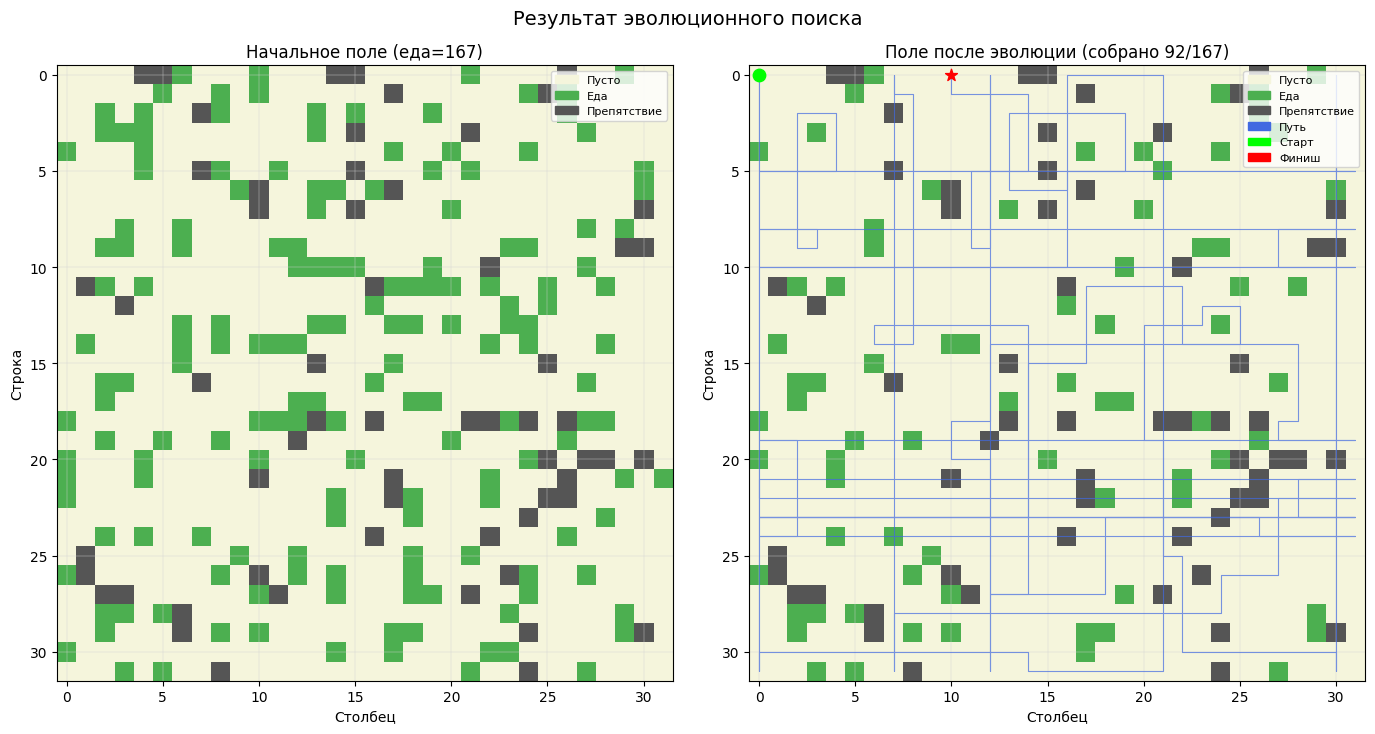

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Левый: начальное поле
plot_field(BASE_FIELD, title=f'Начальное поле (еда={total_on_field})', ax=axes[0])

# Правый: поле после прогона с путём
field_after = BASE_FIELD.copy()
# Убираем съеденную еду
visited_food_r, visited_food_c = [], []
tmp_field = BASE_FIELD.copy()
r0, c0    = START_POS
dir0      = START_DIR
state     = 0
for act in ant_actions:
    if act == ACT_FORWARD:
        nr, nc = next_cell(r0, c0, dir0)
        if tmp_field[nr, nc] != CELL_OBSTACLE:
            r0, c0 = nr, nc
            if tmp_field[r0, c0] == CELL_FOOD:
                tmp_field[r0, c0] = CELL_EMPTY
    elif act == ACT_LEFT:  dir0 = (dir0 - 1) % 4
    elif act == ACT_RIGHT: dir0 = (dir0 + 1) % 4
    elif act == ACT_EAT:
        if tmp_field[r0, c0] == CELL_FOOD:
            tmp_field[r0, c0] = CELL_EMPTY

plot_field(tmp_field, path=ant_path,
           title=f'Поле после эволюции (собрано {food_collected}/{total_on_field})',
           ax=axes[1])

plt.suptitle('Результат эволюционного поиска', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 10. График сходимости эволюционного алгоритма

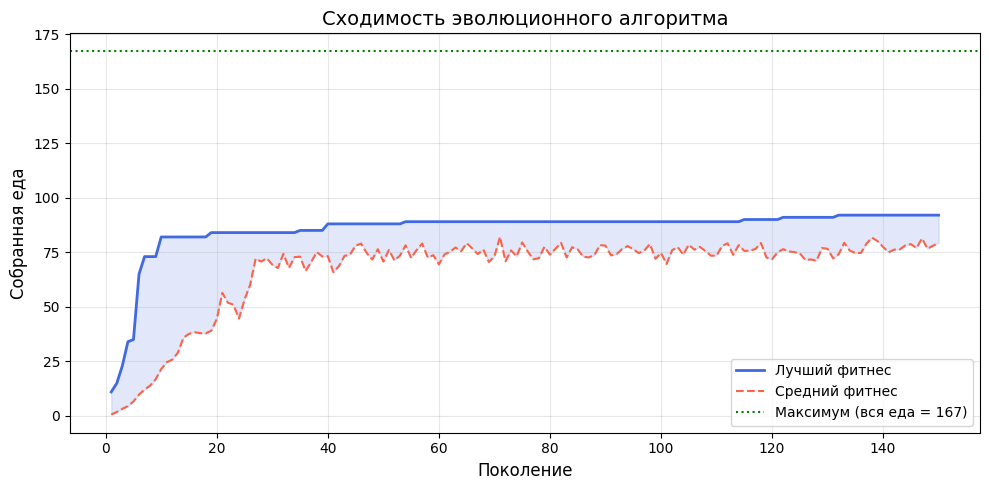

Прирост фитнеса: 11 → 92


In [10]:
best_curve = [h[0] for h in history]
mean_curve = [h[1] for h in history]
gens       = list(range(1, len(history) + 1))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gens, best_curve, color='royalblue', linewidth=2,   label='Лучший фитнес')
ax.plot(gens, mean_curve, color='tomato',    linewidth=1.5,
        linestyle='--', label='Средний фитнес')
ax.axhline(total_on_field, color='green', linestyle=':', linewidth=1.5,
           label=f'Максимум (вся еда = {total_on_field})')
ax.fill_between(gens, mean_curve, best_curve, alpha=0.15, color='royalblue')
ax.set_xlabel('Поколение',  fontsize=12)
ax.set_ylabel('Собранная еда', fontsize=12)
ax.set_title('Сходимость эволюционного алгоритма', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Прирост фитнеса: {best_curve[0]} → {best_curve[-1]}')

## 11. Многократные запуски — статистика

In [11]:
NUM_RUNS = 5
run_results = []

for run_idx in range(NUM_RUNS):
    # Каждый раз новое поле для разнообразия
    field_run = generate_field(seed=run_idx * 7)
    fa_run, hist_run = run_evolution(field_run, verbose=False)
    food_run, _, _   = fa_run.simulate(field_run)
    total_run        = count_food(field_run)
    run_results.append({
        'run'     : run_idx + 1,
        'best_fit': food_run,
        'total'   : total_run,
        'eff'     : round(food_run / total_run * 100, 1),
        'states'  : fa_run.num_states,
        'history' : hist_run
    })
    print(f'Запуск {run_idx+1}: еда={food_run}/{total_run} ({food_run/total_run*100:.1f}%), '
          f'состояний={fa_run.num_states}')

print('\nСтатистика завершена.')

Запуск 1: еда=79/158 (50.0%), состояний=6
Запуск 2: еда=81/153 (52.9%), состояний=6
Запуск 3: еда=71/136 (52.2%), состояний=6
Запуск 4: еда=76/143 (53.1%), состояний=6
Запуск 5: еда=89/160 (55.6%), состояний=7

Статистика завершена.


## 12. Сводный график по запускам

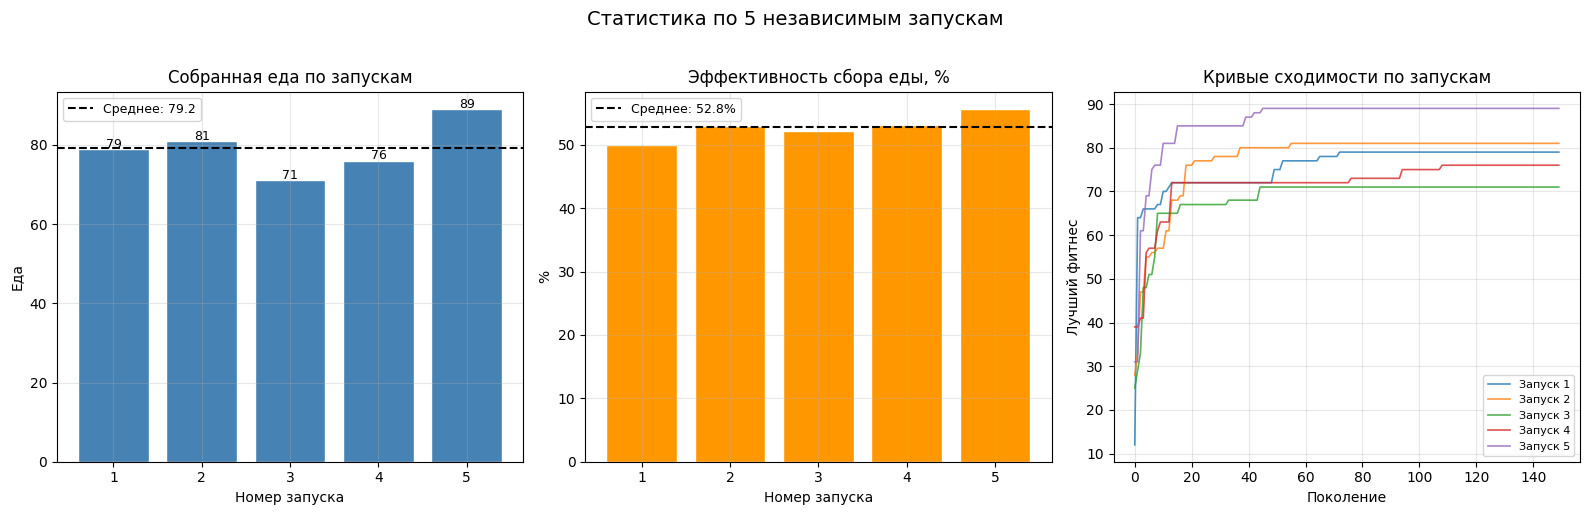

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

runs      = [r['run']      for r in run_results]
best_fits = [r['best_fit'] for r in run_results]
effs      = [r['eff']      for r in run_results]
states    = [r['states']   for r in run_results]

# (1) Собранная еда по запускам
bars = axes[0].bar(runs, best_fits, color='steelblue', edgecolor='white')
axes[0].axhline(np.mean(best_fits), color='black', linestyle='--', linewidth=1.5,
                label=f'Среднее: {np.mean(best_fits):.1f}')
for bar, val in zip(bars, best_fits):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontsize=9)
axes[0].set_title('Собранная еда по запускам', fontsize=12)
axes[0].set_xlabel('Номер запуска'); axes[0].set_ylabel('Еда')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# (2) Эффективность (%)
colors_eff = ['#4caf50' if e >= 60 else '#ff9800' if e >= 40 else '#f44336' for e in effs]
axes[1].bar(runs, effs, color=colors_eff, edgecolor='white')
axes[1].axhline(np.mean(effs), color='black', linestyle='--', linewidth=1.5,
                label=f'Среднее: {np.mean(effs):.1f}%')
axes[1].set_title('Эффективность сбора еды, %', fontsize=12)
axes[1].set_xlabel('Номер запуска'); axes[1].set_ylabel('%')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# (3) Кривые сходимости всех запусков
for r in run_results:
    bc = [h[0] for h in r['history']]
    axes[2].plot(bc, linewidth=1.2, alpha=0.8, label=f'Запуск {r["run"]}')
axes[2].set_title('Кривые сходимости по запускам', fontsize=12)
axes[2].set_xlabel('Поколение'); axes[2].set_ylabel('Лучший фитнес')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Статистика по {NUM_RUNS} независимым запускам', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 13. Итоговый вывод

In [13]:
print('=' * 60)
print('          ИТОГИ ЭВОЛЮЦИОННОЙ ПРОГРАММЫ')
print('=' * 60)
print(f'Поле                  : {GRID_SIZE}×{GRID_SIZE}')
print(f'Плотность еды         : {FOOD_DENSITY*100:.0f}%')
print(f'Плотность препятствий : {OBS_DENSITY*100:.0f}%')
print(f'Алгоритм              : Эволюционная стратегия (ES)')
print(f'Размер популяции      : {POP_SIZE}')
print(f'Поколений             : {NUM_GEN}')
print(f'Элитизм               : {ELITE_FRAC*100:.0f}%')
print('-' * 60)
food_collected_main, _, _ = best_fa.simulate(BASE_FIELD)
print(f'Лучший КА (осн. запуск)')
print(f'  Собрано еды         : {food_collected_main} / {count_food(BASE_FIELD)}')
print(f'  Эффективность       : {food_collected_main/count_food(BASE_FIELD)*100:.1f}%')
print(f'  Состояний в КА      : {best_fa.num_states}')
print('-' * 60)
print(f'Среднее по {NUM_RUNS} запускам : {np.mean(best_fits):.1f} ед. еды  '
      f'({np.mean(effs):.1f}% от total)')
print('=' * 60)

          ИТОГИ ЭВОЛЮЦИОННОЙ ПРОГРАММЫ
Поле                  : 32×32
Плотность еды         : 15%
Плотность препятствий : 5%
Алгоритм              : Эволюционная стратегия (ES)
Размер популяции      : 120
Поколений             : 150
Элитизм               : 10%
------------------------------------------------------------
Лучший КА (осн. запуск)
  Собрано еды         : 92 / 167
  Эффективность       : 55.1%
  Состояний в КА      : 7
------------------------------------------------------------
Среднее по 5 запускам : 79.2 ед. еды  (52.8% от total)
